### **Разведочный анализ данных (EDA)**

## **Прогнозирование динамики акций с помощью машинного обучения**

Данные были собраны с помощью скрипта, использующего **API Московской Биржи** (MOEX ISS)

**Период:** Последние 3 года (с ноября 2022 года по октябрь 2025 года)

**Режим торгов:** TQBR (Основная торговая сессия для акций)

### **Описание признаков**

- `BoardId` — идентификатор режима торгов (*TQBR* — основные торги акциями)
- `TradeDate` — дата совершения торгов
- `ShortName` — краткое название ценной бумаги
- `SecId` — биржевой идентификатор ценной бумаги
- `NumTrades` — количество сделок за торговый день
- `Value` — объем сделок в рублях
- `Open` — цена открытия торгового дня
- `Low` — минимальная цена за торговый день
- `High` — максимальная цена за торговый день
- `LegalClosePrice` — расчетная цена закрытия
- `WaPrice` — средневзвешенная цена за день
- `Close` — цена закрытия торгового дня
- `Volume` — объем сделок в штуках ценных бумаг
- `MarketPrice2`, `MarketPrice3` — различные расчетные рыночные цены
- `AdmittedQuote` — признаваемая котировка
- `Mp2ValTrd`, `MarketPrice3TradesValue`, `AdmittedValue`, `WaVal` — различные показатели стоимости сделок
- `TradingSession` — идентификатор торговой сессии (*3* — основная торговая сессия)
- `CurrencyId` — валюта расчета (*SUR* — российский рубль)
- `TrendClsPr` — изменение цены закрытия в процентах относительно предыдущего дня (**целевая переменная**)
- `TradeSessionDate` — дата торговой сессии
- `SecType` — тип ценной бумаги
- `Year` — год проведения торгов
- `Month` — месяц проведения торгов
- `Quarter` — квартал проведения торгов
- `DayOfWeek` — день недели проведения торгов
- `SecurityType` — тип ценной бумаги (*Обыкновенная*)
- `PriceCategory` — категория цены:
  - Очень низкая: 0 - 10 рублей
  - Низкая: 10 - 50 рублей
  - Средняя: 50 - 100 рублей
  - Высокая: 100 - 500 рублей
  - Очень высокая: 500 - 1000 рублей
  - Экстрим: свыше 1000 рублей
- `VolumeCategory` — категория объема торгов
- `DailyRange` — дневной диапазон цены (разница между High и Low)
- `VolatilityCategory` — категория волатильности

In [63]:
import numpy as np
import pandas as pd
import requests
from datetime import datetime, timedelta
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("data/moex/moex_top30_liquid.csv")
df

,BoardId,TradeDate,ShortName,SecId,NumTrades,Value,Open,Low,High,LegalClosePrice,...,SecType,Year,Month,Quarter,DayOfWeek,SecurityType,PriceCategory,VolumeCategory,DailyRange,VolatilityCategory
0,TQBR,2022-11-02,Сбербанк,SBER,91488,5091797153.100,127.060,123.750,127.740,127.140,...,1,2022,11,4,Wednesday,Обыкновенная,Высокая,Очень высокий,3.990,Средняя
1,TQBR,2022-11-03,Сбербанк,SBER,103937,5968383629.500,125.400,123.910,126.100,125.450,...,1,2022,11,4,Thursday,Обыкновенная,Высокая,Очень высокий,2.190,Низкая
2,TQBR,2022-11-07,Сбербанк,SBER,189795,11884172361.200,127.090,126.500,132.000,131.630,...,1,2022,11,4,Monday,Обыкновенная,Высокая,Очень высокий,5.500,Средняя
3,TQBR,2022-11-08,Сбербанк,SBER,143560,9132676225.500,132.000,130.100,133.110,131.170,...,1,2022,11,4,Tuesday,Обыкновенная,Высокая,Очень высокий,3.010,Низкая
4,TQBR,2022-11-09,Сбербанк,SBER,127792,8392114411.700,131.060,126.420,131.470,128.290,...,1,2022,11,4,Wednesday,Обыкновенная,Высокая,Очень высокий,5.050,Средняя
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20775,TQBR,2025-10-27,iПозитив,POSI,12854,539920604.400,1118.800,1050.400,1118.800,1083.000,...,1,2025,10,4,Monday,Обыкновенная,Экстрим,Низкий,68.400,Высокая
20776,TQBR,2025-10-28,iПозитив,POSI,10759,462248795.200,1052.000,1038.000,1095.400,1084.800,...,1,2025,10,4,Tuesday,Обыкновенная,Экстрим,Низкий,57.400,Высокая
20777,TQBR,2025-10-29,iПозитив,POSI,7904,283765575.600,1073.000,1073.000,1099.000,1083.800,...,1,2025,10,4,Wednesday,Обыкновенная,Экстрим,Низкий,26.000,Высокая
20778,TQBR,2025-10-30,iПозитив,POSI,8982,335813370.600,1080.200,1072.400,1125.400,1121.400,...,1,2025,10,4,Thursday,Обыкновенная,Экстрим,Низкий,53.000,Высокая


## **1. Изучение особенности данных**

Рассчитаем основные статистики для вещественных и категориальных признаков

In [65]:
print("Размер датасета:", df.shape)

Размер датасета: (20780, 34)


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BoardId                  20780 non-null  object 
 1   TradeDate                20780 non-null  object 
 2   ShortName                20780 non-null  object 
 3   SecId                    20780 non-null  object 
 4   NumTrades                20780 non-null  int64  
 5   Value                    20780 non-null  float64
 6   Open                     20780 non-null  float64
 7   Low                      20780 non-null  float64
 8   High                     20780 non-null  float64
 9   LegalClosePrice          20780 non-null  float64
 10  WaPrice                  20780 non-null  float64
 11  Close                    20780 non-null  float64
 12  Volume                   20780 non-null  int64  
 13  MarketPrice2             20780 non-null  float64
 14  MarketPrice3          

In [67]:
desc_object = df.describe(include='object')
desc_object.to_csv('data/eda/eda_summary_object.csv')
desc_object

,BoardId,TradeDate,ShortName,SecId,CurrencyId,TradeSessionDate,DayOfWeek,SecurityType,PriceCategory,VolumeCategory,VolatilityCategory
count,20780,20780,20780,20780,20780,5157,20780,20780,20780,20780,20780
unique,1,764,30,30,1,172,6,2,6,4,3
top,TQBR,2025-10-23,Сбербанк,SBER,SUR,2025-03-03,Friday,Обыкновенная,Высокая,Очень высокий,Низкая
freq,20780,30,764,764,20780,30,4163,18492,6702,5195,6936


`BoardId` и `CurrencyId` имеют по одному уникальному значению. Удалим их

In [68]:
df = df.drop(columns=['BoardId', 'CurrencyId'], errors='ignore')
print("Размер датасета:", df.shape)

Размер датасета: (20780, 32)


Наиболее частый день недели — пятница (4163 раза), что может быть связано с особенностями выборки или повышенной активностью в конце недели

В данных представлено 30 уникальных ценных бумаг (`ShortName`, `SecId`)

Наиболее частый инструмент — Сбербанк (SBER)

In [69]:
# список ценных бумаг
list(df.ShortName.unique())

['Сбербанк',
 'ГАЗПРОМ ао',
 'Т-Техно ао',
 'ВТБ ао',
 'ЛУКОЙЛ',
 'Новатэк ао',
 'Самолет ао',
 'ЯНДЕКС',
 'ГМКНорНик',
 'КЦ ИКС 5',
 'Роснефть',
 'Полюс',
 'ПИК ао',
 'Аэрофлот',
 'Мечел ао',
 'Система ао',
 'Татнфт 3ао',
 'МосБиржа',
 'МКПАО "ВК"',
 'Транснф ап',
 'РуссНфт ао',
 'Сургнфгз-п',
 'НЛМК ао',
 'СевСт-ао',
 'Русагро',
 'Сургнфгз',
 'Сбербанк-п',
 'ММК',
 'АЛРОСА ао',
 'iПозитив']

In [70]:
# количество акций по компаниям
df.ShortName.value_counts()

ShortName
Сбербанк      764
ГАЗПРОМ ао    764
Новатэк ао    764
ЛУКОЙЛ        764
Аэрофлот      764
Самолет ао    764
ПИК ао        764
Роснефть      764
РуссНфт ао    764
Сургнфгз-п    764
МосБиржа      764
Татнфт 3ао    764
Система ао    764
Мечел ао      764
АЛРОСА ао     764
ММК           764
Сургнфгз      764
Сбербанк-п    764
iПозитив      764
НЛМК ао       764
СевСт-ао      764
Полюс         761
ВТБ ао        760
Транснф ап    760
ГМКНорНик     760
МКПАО "ВК"    741
ЯНДЕКС        327
Т-Техно ао    236
КЦ ИКС 5      209
Русагро       182
Name: count, dtype: int64

In [71]:
# категории цены
list(df.PriceCategory.unique())

['Высокая', 'Экстрим', 'Очень низкая', 'Средняя', 'Очень высокая', 'Низкая']

In [72]:
# категории объема торгов цены
list(df.VolumeCategory.unique())

['Очень высокий', 'Высокий', 'Средний', 'Низкий']

In [73]:
# категории волатильности
list(df.VolatilityCategory.unique())

['Средняя', 'Низкая', 'Высокая']

In [74]:
# тип ценной бумаги
list(df.SecurityType.unique())

['Обыкновенная', 'Привилегированная']

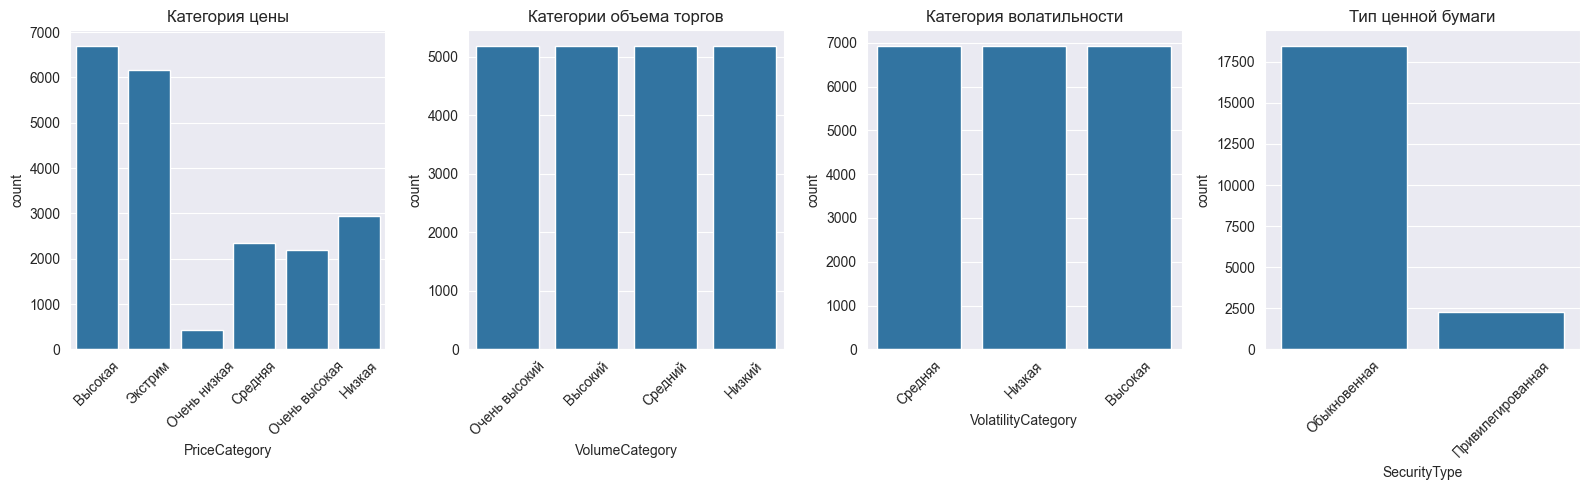

In [75]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

sns.countplot(data=df, x='PriceCategory', ax=axes[0])
axes[0].set_title('Категория цены')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='VolumeCategory', ax=axes[1])
axes[1].set_title('Категории объема торгов')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='VolatilityCategory', ax=axes[2])
axes[2].set_title('Категория волатильности')
axes[2].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='SecurityType', ax=axes[3])
axes[3].set_title('Тип ценной бумаги')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Распределение **ценовых категорий** показывает, что большинство записей приходится на категории «Высокая» (около 6700) и «Экстрим» (около 6200). Это говорит о том, что в выборке доминируют акции с высокой стоимостью — от 500 до 1000 ₽ и выше.

Категории «Средняя» (около 2300), «Низкая» (около 2900) и «Очень низкая» (около 400) представлены значительно слабее.

Датасет не сбалансирован по ценовым категориям — он перекошен в сторону дорогих бумаг. Однако на Московской бирже подавляющее большинство ликвидных эмитентов выпускают в первую очередь обыкновенные акции. Привилегированные акции — это скорее исключение, чем правило: их выпускают лишь отдельные компании

**Объёмы торгов** распределены равномерно по квантилям — значит данные хорошо охватывают весь спектр ликвидности

Распределение **волатильности** также почти равномерное

Обыкновенных бумаг намного больше чем привилегированных. Связано это с тем, что при сборе данных были выбраны по обороту (`Value`)

Теперь рассмотрим статистику по вещенственным признакам

In [76]:
pd.set_option('display.float_format', '{:.3f}'.format)
desc_all = df.describe(exclude='object').T
desc_all.to_csv('data/eda/eda_summary.csv', float_format='%.3f')
desc_all

,count,mean,std,min,25%,50%,75%,max
NumTrades,20780.000,43356.606,45068.533,126.000,17763.500,31203.500,53062.500,1125241.000
Value,20780.000,2515518672.070,3867642601.840,6867232.100,665354109.300,1311022713.815,2667144510.100,87982590489.000
Open,20780.000,3342.707,15652.683,0.016,81.008,268.985,1250.000,167000.000
Low,20780.000,3300.675,15468.496,0.016,79.475,265.905,1228.850,165550.000
High,20780.000,3378.743,15808.712,0.016,82.190,272.185,1272.000,167950.000
LegalClosePrice,20780.000,3342.055,15656.153,0.016,80.760,269.000,1247.650,166400.000
WaPrice,20780.000,3341.472,15651.123,0.016,80.808,269.195,1247.400,166850.000
Close,20780.000,3342.992,15660.114,0.016,80.895,268.675,1249.800,166850.000
Volume,20780.000,2403970864.759,22389963093.830,163.000,955300.500,4340965.500,20225737.250,703268100000.000
MarketPrice2,20780.000,3341.489,15651.279,0.016,80.800,269.225,1247.450,166950.000


Минимальные значения близки к нулю (0.016), а максимальные достигают 167 000, что говорит о наличии как низколиквидных активов, так и высокодоходных инструментов

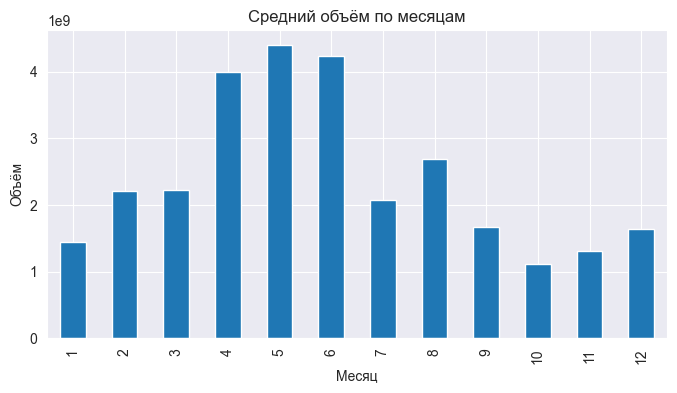

In [77]:
# Объём по месяцам
df.groupby('Month')['Volume'].mean().plot(kind='bar', figsize=(8, 4))
plt.title('Средний объём по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Объём')
plt.show()

Самые высокие объёмы приходятся на май и июнь — это пики активности.
Значительный спад наблюдается в октябре — самый низкий объём за весь год.
Умеренно высокие объёмы — в апреле, августе, сентябре.
Низкие объёмы — в январе, феврале, ноябре, декабре.

Это типичный сезонный паттерн на российском рынке:

- Май–июнь — период отчётности, когда инвесторы активно пересматривают портфели, и растёт ликвидность.
- Октябрь — традиционно слабый месяц, часто связанный с началом осени и снижением интереса к рынку.
- Январь–февраль — после новогодних праздников активность ещё невысока.
- Декабрь — предновогодний «сброс» позиций, что также снижает объёмы.

Источник: https://www.finam.ru/publications/item/sezonnost-na-fondovom-rynke-rossii-20250623-1807/

`Mp2ValTrd` и `MarketPrice3TradesValue` полностью идентичны по статистике - вероятно, дублирующие признаки. Удалим их

In [78]:
df = df.drop(columns=['Mp2ValTrd', 'MarketPrice3TradesValue'], errors='ignore')
print("Размер датасета:", df.shape)

Размер датасета: (20780, 30)


`WaVal` - полностью нулевой признак (все значения 0)

`TradingSession` - константа (все значения 3.000)

Эти признаки не несут информационной ценности и могут быть удалены

In [79]:
df = df.drop(columns=['WaVal', 'TradingSession'], errors='ignore')
print("Размер датасета:", df.shape)

Размер датасета: (20780, 28)


**Пропуски**

In [80]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Пропущено': missing,
    'Доля (%)': missing_pct.round(2)
}).sort_values('Пропущено', ascending=False)

missing_summary

,Пропущено,Доля (%)
AdmittedQuote,19454,93.620
AdmittedValue,19454,93.620
TradeSessionDate,15623,75.180
TrendClsPr,3,0.010
Value,0,0.000
Open,0,0.000
Low,0,0.000
High,0,0.000
TradeDate,0,0.000
ShortName,0,0.000


Датасет считается разреженным, когда значительная часть признаков имеет высокий процент пропущенных значений

Большая доля пропусков встречается у 3х признаков -  `AdmittedQuote`, `AdmittedValue` и `TradeSessionDate`.

Это возникают потому, что не все режимы торгов или типы бумаг предоставляют эти метрики

Удалим эти признаки (так как большая доля пропусков ~93%)

In [81]:
df = df.drop(columns=['AdmittedQuote', 'AdmittedValue', 'TradeSessionDate'], errors='ignore')
print("Размер датасета:", df.shape)

Размер датасета: (20780, 25)


**Ошибочные значения**

Для дневных биржевых данных по акциям ошибочными могут быть:
1. Цены ≤ 0,
2. Объёмы или обороты < 0,
3. Нарушение логики ценового диапазона:
    - HIGH < LOW,
    - OPEN или CLOSE вне диапазона [LOW, HIGH].

По таблице можем увидеть

 - Минимальное значение `Open` = 0.016, `Low` = 0.016 => все цены строго положительные
 - Минимальный `Value` > 0, `NumTrades` > 0 => нет отрицательных объёмов или оборотов.

In [82]:
# проверка на наличие некорретных данных
df_clean = df[
    (df['Open'] > 0) &
    (df['Close'] > 0) &
    (df['High'] >= df['Low']) &
    (df['Open'] >= df['Low']) & (df['Open'] <= df['High']) &
    (df['Close'] >= df['Low']) & (df['Close'] <= df['High']) &
    (df['Volume'] >= 0) &
    (df['Value'] >= 0)
]

len(df_clean) == len(df)

True

Данные идентичны с прежними. Некорректные данные по этим условиям отсутствуют

In [83]:
# Проверка торговли бумагами в выходные дни
len(df[df['DayOfWeek']=='Saturday'])

81

In [84]:
df[df['DayOfWeek']=='Saturday']['TradeDate'].unique()

array(['2024-04-27', '2024-11-02', '2024-12-28'], dtype=object)

Присутствуют торговля бумагами в выходные дни. Но можем заметить, что данные не является корректными, так как торговля официально проводилась в эти дни (Календарь работы биржы - https://www.moex.com/msn/ru-fx-calendar?year=2024)

In [85]:
len(df[df['DayOfWeek']=='Sunday'])

0

В воскренье биржа не работала

Удалим данные с днем недели суббота, их не так много (81 шт)

In [86]:
df = df[df['DayOfWeek'] != 'Saturday']
df['DayOfWeek'].unique()

array(['Wednesday', 'Thursday', 'Monday', 'Tuesday', 'Friday'],
      dtype=object)

**Выбросы**

`Volume` имеет экстремально высокий разброс (std=22 млрд при mean=2.4 млрд), с максимальным значением 703 млрд, что указывает на наличие **выбросов**.

C:\Users\mifmi\AppData\Local\Temp\ipykernel_18208\3482175082.py:8: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mifmi\AppData\Local\Temp\ipykernel_18208\3482175082.py:8: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
D:\YandexDisk\idenisger\Edu\StocksForecast\ai_portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\YandexDisk\idenisger\Edu\StocksForecast\ai_portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


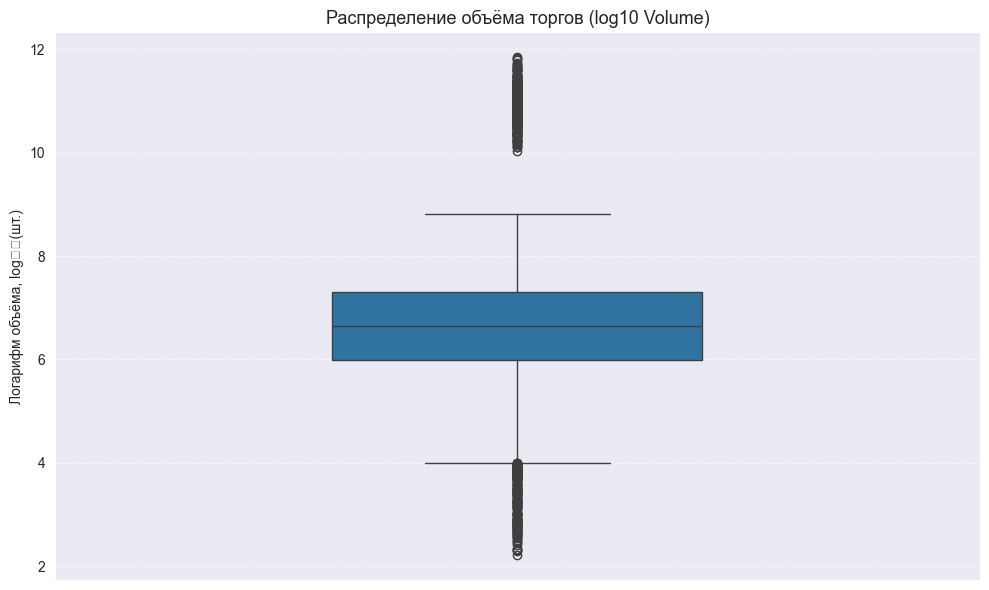

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.boxplot(y=np.log10(df['Volume']), ax=ax, width=0.4)
ax.set_title('Распределение объёма торгов (log10 Volume)', fontsize=13)
ax.set_ylabel('Логарифм объёма, log₁₀(шт.)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Несмотря на выбросы, основная часть данных (коробка и "усы") сосредоточена в относительно узком диапазоне - примерно от log10=6 до log10=8. Это значит, что в 50% случаев объем торгов колеблется в пределах от 1 млн до 100 млн штук.

Также нижняя граница "усов" находится на уровне log10=4, что соответствует 10^4 = 10 тысячам штук. Это показывает, что существуют дни с очень низкой активностью, что может быть полезно для стратегий, ориентированных на "тихие" периоды.

## **2. Изучение признаков**


В качестве *целевой переменной* был взят признак `TrendClsPr` -  изменение цены закрытия в процентах относительно предыдущего дня.

`TrendClsPr` является чиловой переменной, а также отражает динамику рынка: рост или падение цены акции. Все остальные признаки (цена открытия, объём, волатильность и тд) - факторы, которые могут влиять на изменение цены

Изучим поведение признаков, их связь с целевой переменной, а также попарные корреляции

In [88]:
mean_trend = df['TrendClsPr'].mean()
median_trend = df['TrendClsPr'].median()
std_trend = df['TrendClsPr'].std()

print(f"Среднее: {mean_trend:.3f}%")
print(f"Медиана: {median_trend:.3f}%")
print(f"Стандартное отклонение: {std_trend:.3f}%")

Среднее: 0.020%
Медиана: -0.070%
Стандартное отклонение: 2.106%


В среднем цена акций почти не растёт и не падает от дня к дню. А половина дней заканчивается с небольшим падением цены.

Типичные колебания цены за день - около +/-2%

In [89]:
# Выбросы: значения за пределами +/-10%
outliers = df[(df['TrendClsPr'] > 10) | (df['TrendClsPr'] < -10)]
print(f"\nКоличество выбросов (|TrendClsPr| > 10%): {len(outliers)} из {len(df)}")
if not outliers.empty:
    print("Примеры выбросов:")
    print(outliers[['TradeDate', 'ShortName', 'TrendClsPr']].head())


Количество выбросов (|TrendClsPr| > 10%): 48 из 20699
Примеры выбросов:
       TradeDate   ShortName  TrendClsPr
93    2023-03-17    Сбербанк      10.340
544   2024-12-20    Сбербанк      12.490
1544  2024-12-20  Т-Техно ао      11.930
1858  2023-03-20      ВТБ ао      13.810
2304  2024-12-20      ВТБ ао      10.510


Выбросов - 48 случаев из 20 780 (менее 0.25%) - дни с очень сильным скачком или падением (более +-10%)

Возьмем нашу целевую переменную и построим, как она связана с другими числовыми признаками.

Для каждой пары построим scatter plot

также вычислим корреляции коэффициент корреляции Спирмена - число от -1 до 1, которое показывает, насколько сильно два признака связаны друг с другом

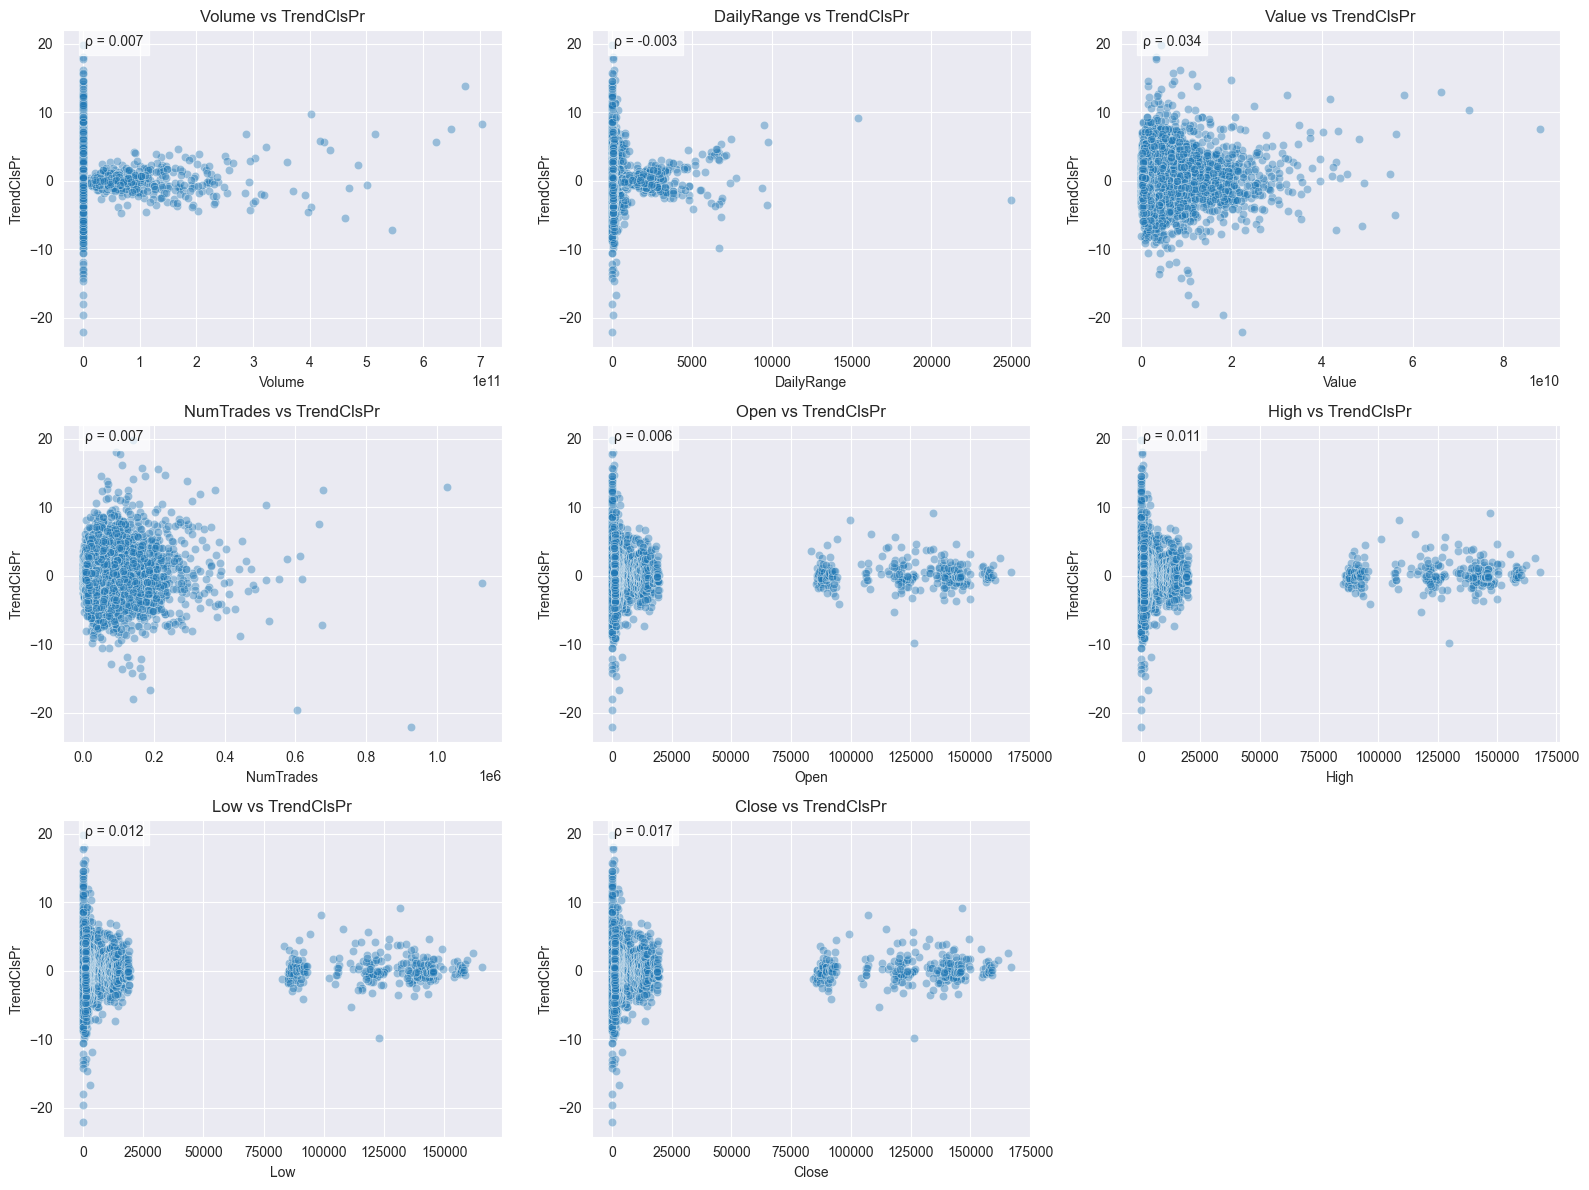

Корреляции (Спирмена) с TrendClsPr:
Value       :  0.034
Close       :  0.017
Low         :  0.012
High        :  0.011
NumTrades   :  0.007
Volume      :  0.007
Open        :  0.006
DailyRange  : -0.003


In [90]:
numeric_features = ['Volume', 'DailyRange', 'Value', 'NumTrades', 'Open', 'High', 'Low', 'Close']

# Построим scatter plot и посчитаем корреляции
correlations = {}

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=df[col], y=df['TrendClsPr'], alpha=0.4)
    plt.title(f'{col} vs TrendClsPr')
    plt.xlabel(col)
    plt.ylabel('TrendClsPr')

    # Корреляция Спирмена
    corr = df[col].corr(df['TrendClsPr'], method='spearman')
    correlations[col] = corr
    plt.text(0.05, 0.95, f'ρ = {corr:.3f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# Выведем корреляции
print("Корреляции (Спирмена) с TrendClsPr:")
for col, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{col:12}: {corr: .3f}")

Все коэффициенты очень близки к нулю - это означает, что никакой из этих признаков не позволяет предсказать, будет ли цена расти или падать завтра

На графиках это тоже видно: точки хаотично разбросаны, нет чёткой тенденции — ни роста, ни падения

Такие результаты скорее всего из-за того, что изменение цены зависит не от одного фактора, а от множества. Все признаки учесть на данный момент не получается

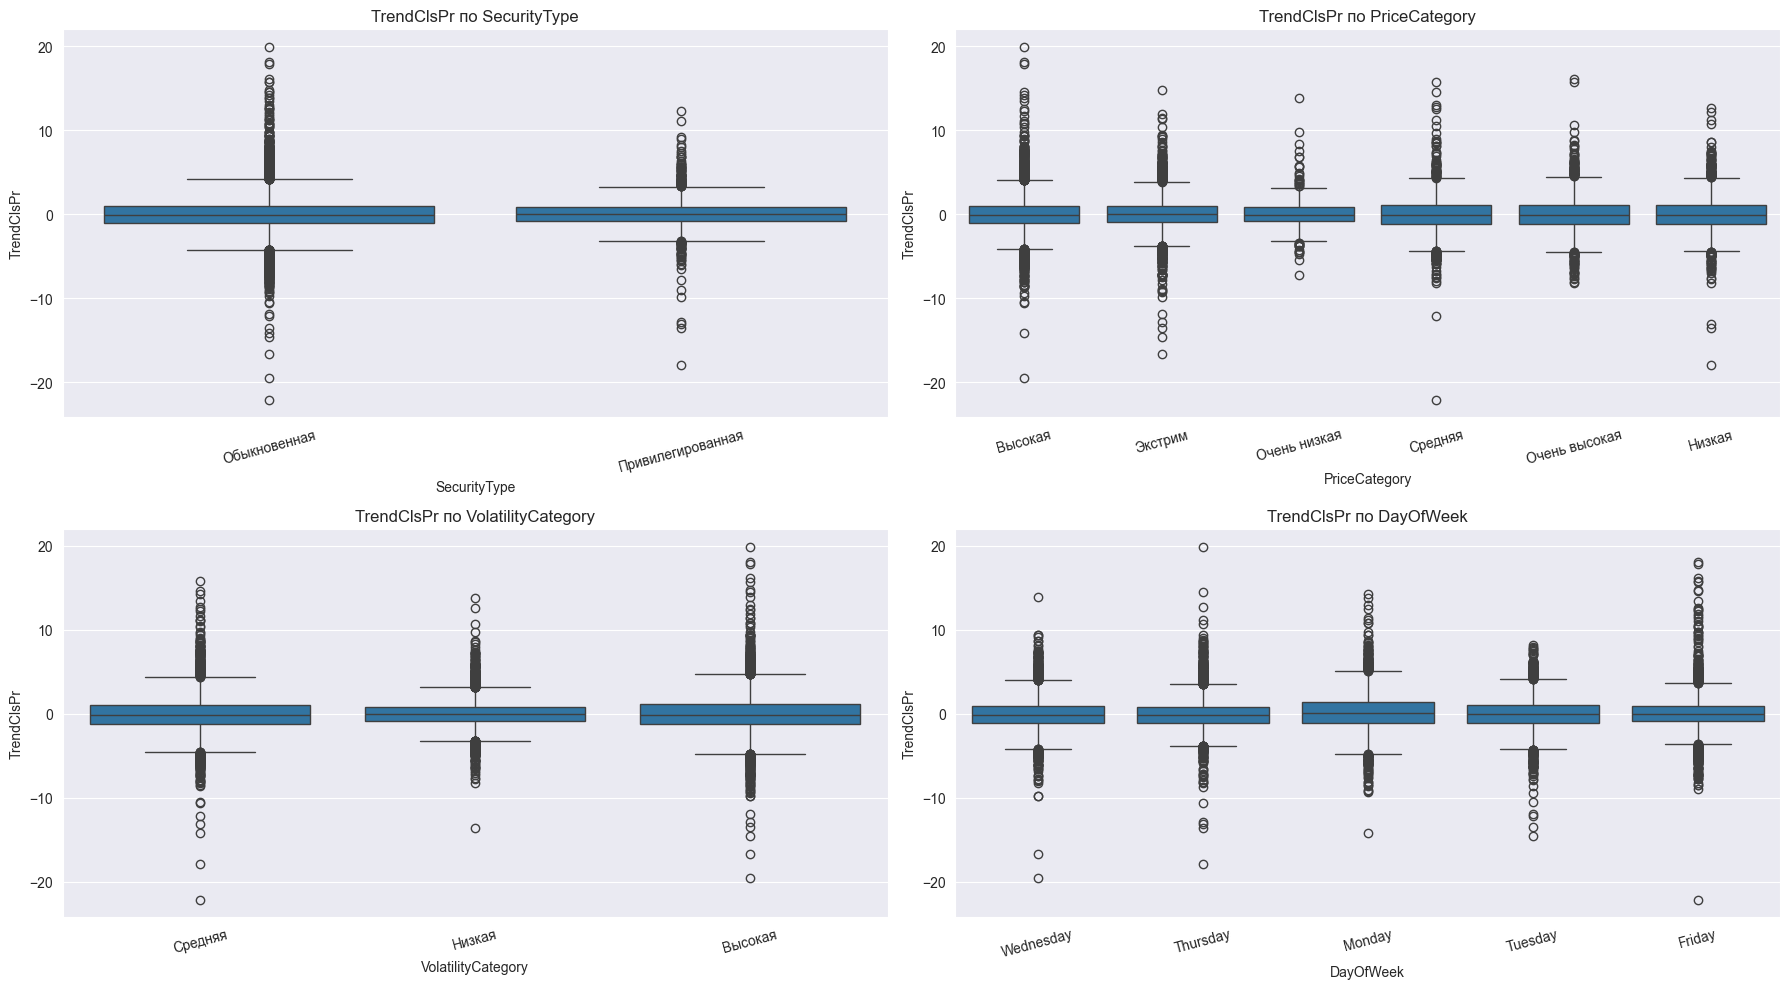


Среднее значение TrendClsPr по категориям:


SecurityType:
                   mean   std  count
SecurityType                        
Обыкновенная      0.014 2.144  18417
Привилегированная 0.076 1.774   2279

PriceCategory:
                mean   std  count
PriceCategory                    
Высокая        0.029 2.204   6674
Низкая        -0.008 2.101   2928
Очень высокая  0.014 2.138   2183
Очень низкая   0.061 1.990    425
Средняя       -0.012 2.183   2339
Экстрим        0.037 1.961   6147

VolatilityCategory:
                    mean   std  count
VolatilityCategory                   
Высокая            0.038 2.367   6901
Низкая             0.013 1.640   6904
Средняя            0.010 2.240   6891

DayOfWeek:
            mean   std  count
DayOfWeek                    
Friday     0.065 2.177   4163
Monday     0.174 2.284   4111
Thursday  -0.021 1.985   4129
Tuesday   -0.056 2.003   4132
Wednesday -0.060 2.057   4161


In [91]:
categorical_features = ['SecurityType', 'PriceCategory', 'VolatilityCategory', 'DayOfWeek']

plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x=col, y='TrendClsPr')
    plt.title(f'TrendClsPr по {col}')
    plt.xticks(rotation=15)
    plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# среднее значение TrendClsPr по категориям
print("\nСреднее значение TrendClsPr по категориям:\n")
for col in categorical_features:
    summary = df.groupby(col)['TrendClsPr'].agg(['mean', 'std', 'count']).round(3)
    print(f"\n{col}:")
    print(summary)


`SecurityType`

Нет существенной разницы в изменении цены между обычными и привилегированными акциями. Обе группы ведут себя почти одинаково

`PriceCategory`

*Самые дешёвые* акции (Очень низкая) и *самые дорогие* (Экстрим) показывают наибольший средний рост. Это может быть связано с тем, что дешёвые акции легче "подпрыгивают" в процентах, а дорогие - это часто голубые фишки, которые стабильно растут

На графике видно, что у всех категорий распределения похожи - все они симметричны вокруг нуля, с большим количеством выбросов. Значит, цена акции не сильно влияет на её динамику в процентах - и дешёвые, и дорогие акции могут как расти, так и падать

`VolatilityCategory`

Акции с высокой волатильностью в среднем растут быстрее. Это логично - более волатильные акции чаще совершают резкие движения.

На графике видно, что у "Высокой" волатильности самый широкий ящик и длинные усы - значит, там больше разброса, больше экстремальных движений (и вверх, и вниз). Но в среднем - рост.

`DayOfWeek`

По данным, понедельник - самый "прибыльный" день недели. Возможно, это связано с тем, что после выходных накапливается информация, и рынок реагирует - начинается рост. А вторник и среда - дни коррекции.

Построим следующие графики

*Гистограммы распределения всех числовых признаков*

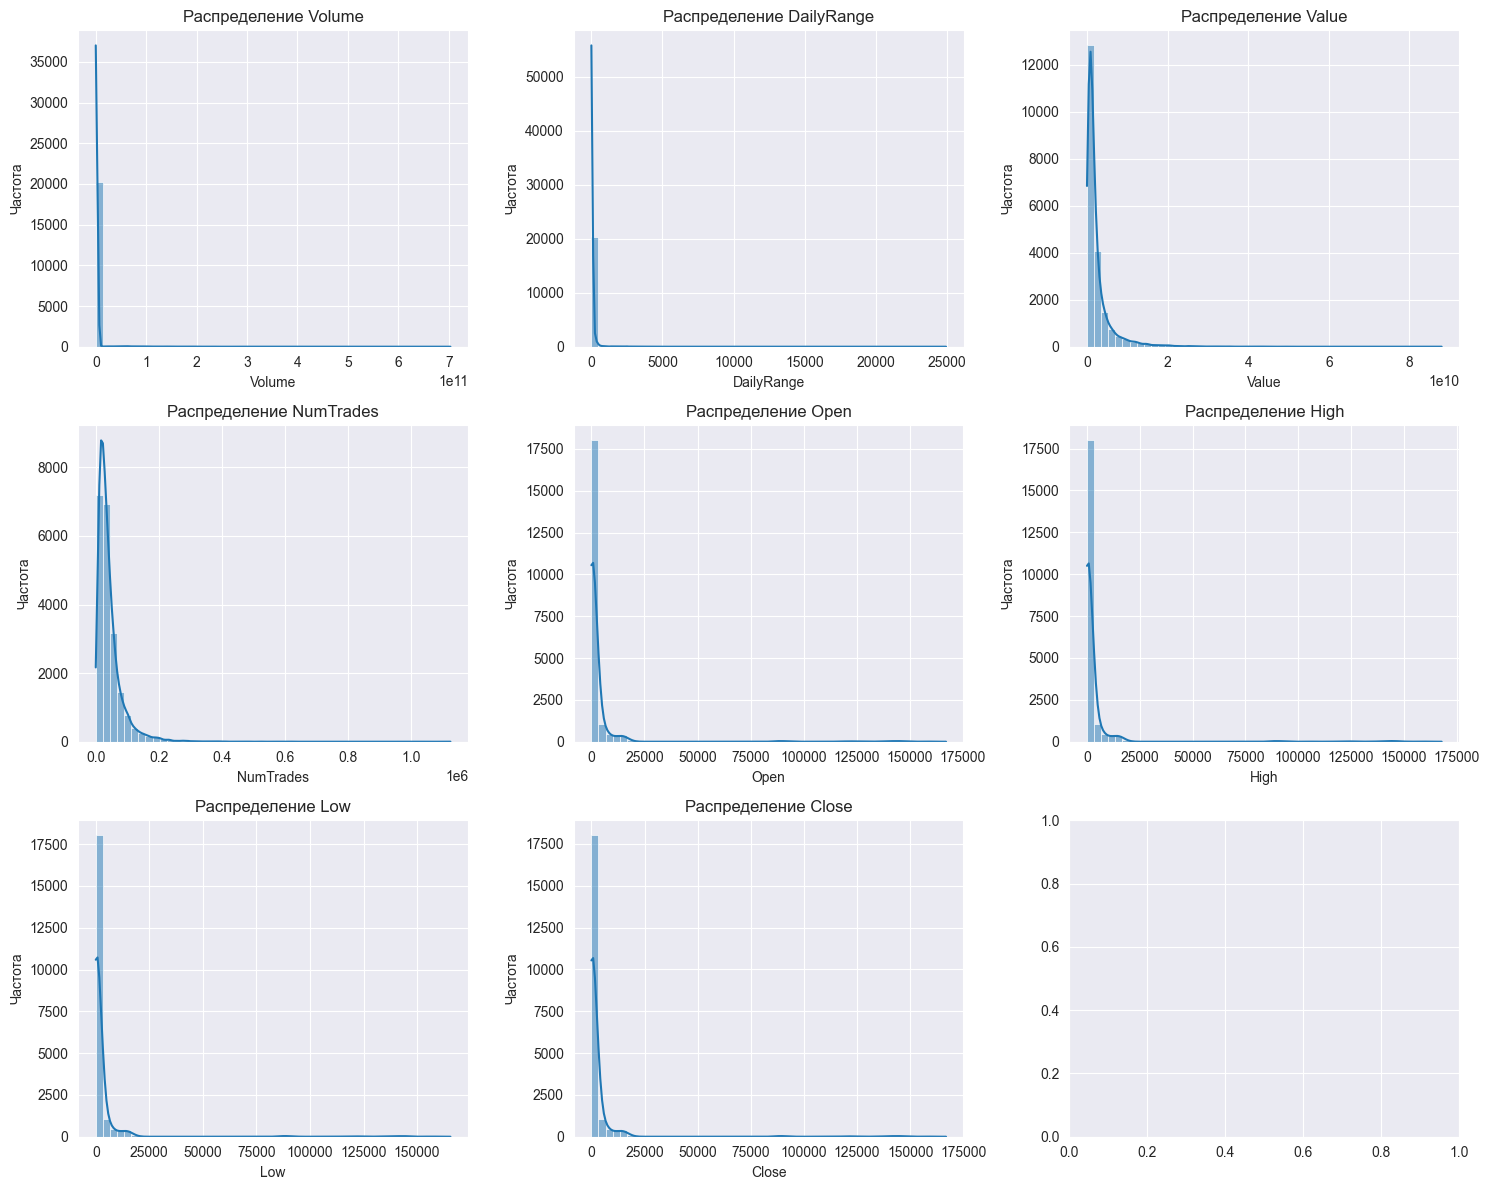

In [92]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

*Попарные распределения числовых признаков*

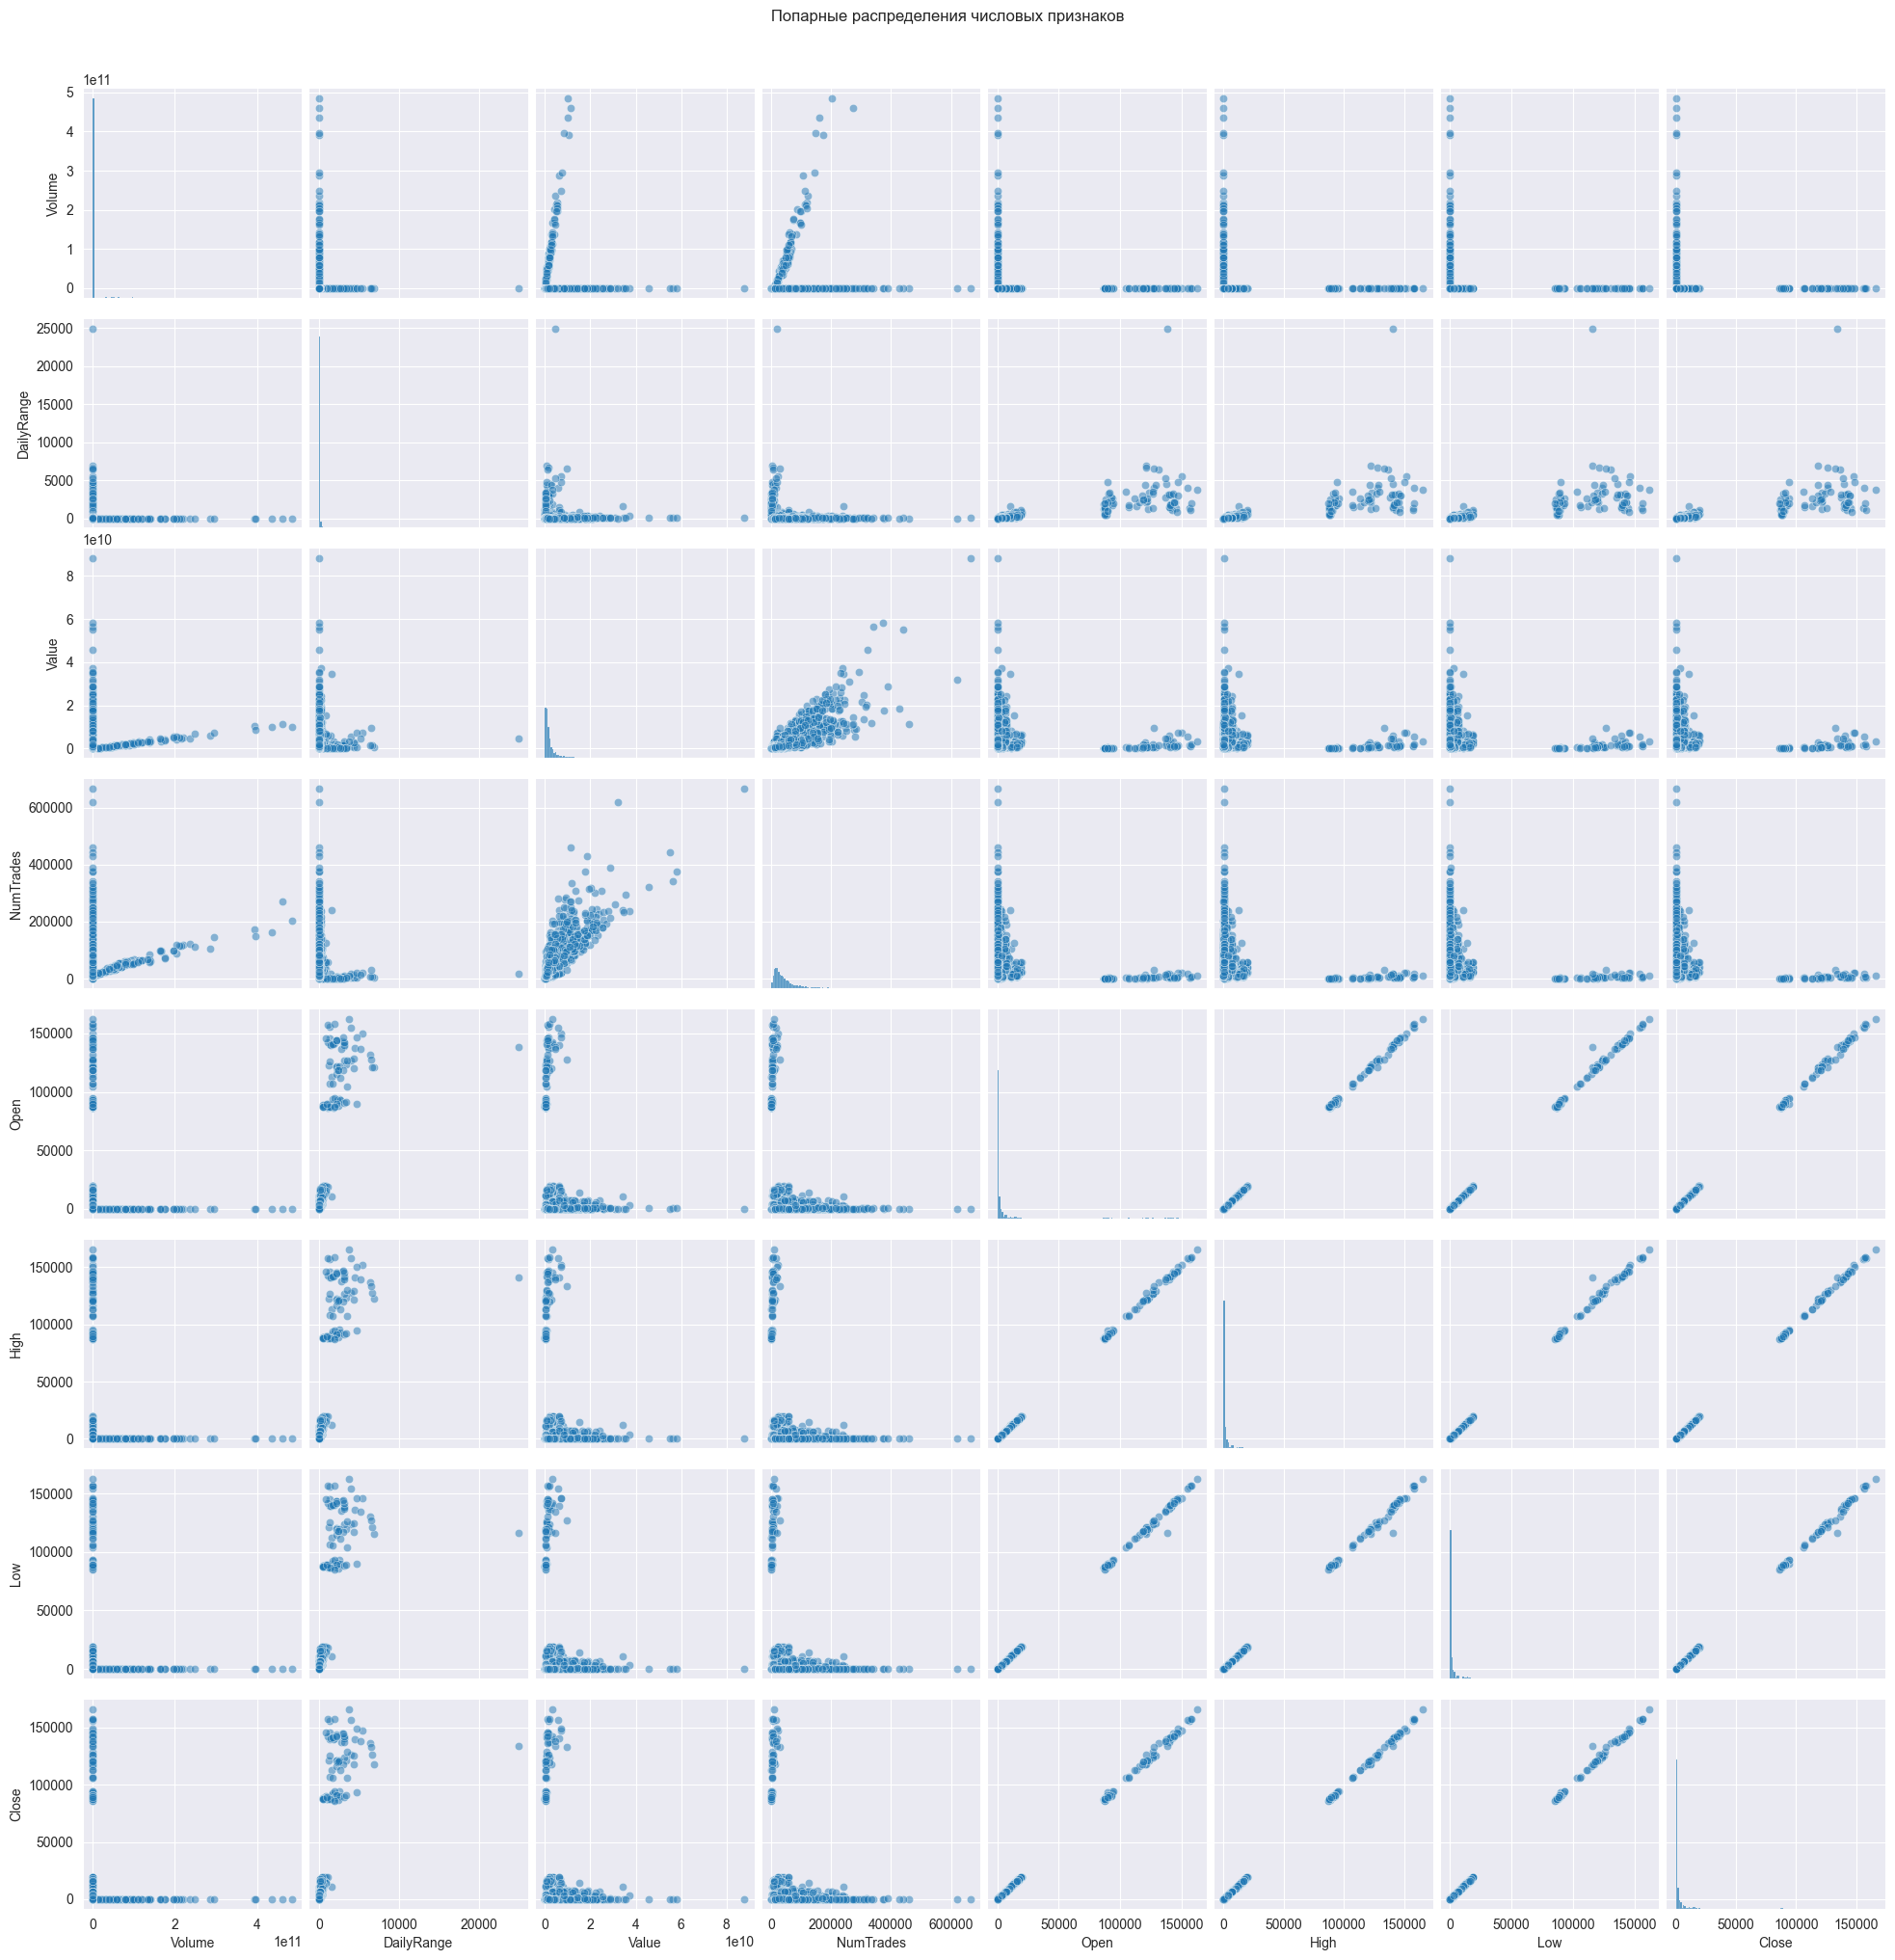

In [93]:
df_sample = df[numeric_features].sample(n=min(5000, len(df)), random_state=42)

sns.pairplot(df_sample, diag_kind='hist', plot_kws={'alpha': 0.5})
plt.suptitle('Попарные распределения числовых признаков', y=1.02)
plt.show()

*Тепловая карта корреляций (heatmap) всех числовых признаков*

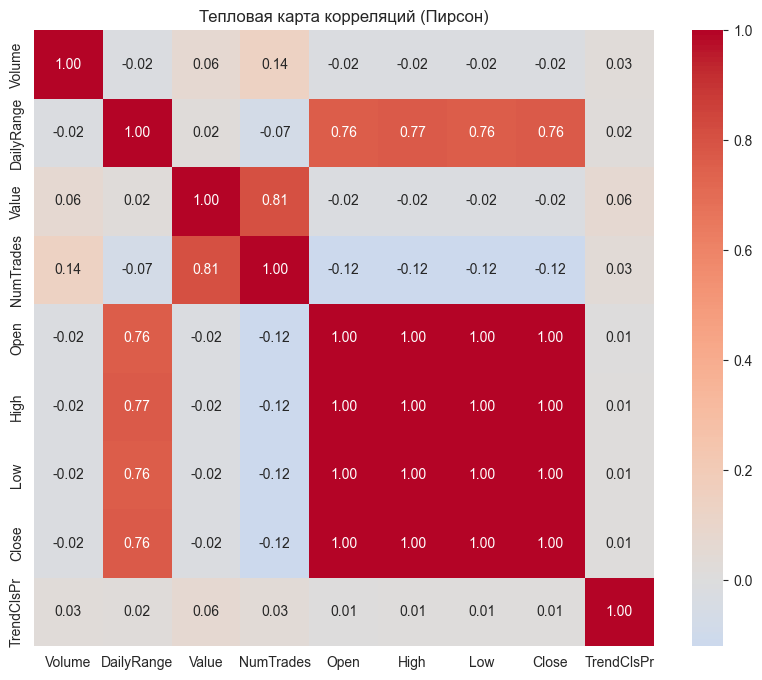

In [94]:
numeric_features = ['Volume', 'DailyRange', 'Value', 'NumTrades', 'Open', 'High', 'Low', 'Close', 'TrendClsPr']

corr_matrix = df[numeric_features].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Тепловая карта корреляций (Пирсон)')
plt.show()

Признаки `Open`, `High`, `Low`, `Close` сильно коррелируют между собой (r = 1ю0), потому что это цены в течение одного дня - они естественно связаны

`Value` (объём в рублях) и `NumTrades` (количество сделок) также сильно коррелируют (0.81), что говорит о том, что дни с большим количеством сделок часто сопровождаются большим объёмом торгов

целевая переменная `TrendClsPr` практически не имеет линейной связи с другими признаками. Скорее всего изменение цены закрытия за день нельзя предсказать по одному из этих числовых признаков, используя линейную модель